# ROI de marketing por canal

**Pregunta de negocio:** ¿cuánto gastamos por canal de marketing vs. el revenue que genera? (CAC, ROAS, gasto vs. presupuesto).

**Fuente de datos:** `fct_marketing_performance` (grano canal x fecha), ya trae `cac`, `roas`, `spend_share`, `attributed_revenue` y `attributed_new_customers` calculados en dbt.

**Caveat de atribución (importante):** ningún pedido/pago trae un campo de canal de marketing en los datos de origen -- no hay atribución real a nivel de orden. El revenue y los clientes nuevos del día se reparten entre los canales activos ese día en proporción a su share de gasto (`spend_share`). Es una estimación explícita del negocio, no un hecho medido -- se trata como tal en todo este notebook.

**Caveat de presupuesto:** `budget_target` es `NULL` para todo el histórico Olist (2016-2018) -- el Sheet de metas solo cubre el año en curso, no hay backfill retroactivo. La comparación gasto-vs-meta solo tiene sentido en los meses donde `budget_target` no es nulo.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
DATA_DIR = Path("../data/raw")

perf = pd.read_parquet(DATA_DIR / "fct_marketing_performance.parquet")
perf["date_day"] = pd.to_datetime(perf["date_day"])
perf["month"] = perf["date_day"].dt.to_period("M").dt.to_timestamp()
perf.shape

(4388, 10)

In [2]:
perf.head()

,date_day,channel,spend,spend_share,attributed_revenue,attributed_new_customers,budget_target,cac,roas,month
0,2017-09-04,Instagram Ads,1925.17,0.273257,7847.724898,39.622222,NaN,48.588138,4.076380,2017-09-01
1,2018-07-03,Email Marketing,1208.12,0.226198,7114.973535,47.727818,NaN,25.312701,5.889294,2018-07-01
2,2017-11-20,Instagram Ads,1534.01,0.181236,9174.388052,40.596851,NaN,37.786429,5.980657,2017-11-01
3,2017-09-26,Email Marketing,1699.74,0.227534,5755.788279,40.273562,NaN,42.204859,3.386276,2017-09-01
4,2018-05-06,Google Ads,333.18,0.083798,2773.648920,16.927153,NaN,19.683168,8.324776,2018-05-01


## Gasto y revenue atribuido, totales por canal

In [3]:
by_channel = perf.groupby("channel").agg(
    spend=("spend", "sum"),
    attributed_revenue=("attributed_revenue", "sum"),
    attributed_new_customers=("attributed_new_customers", "sum"),
).round(2)
by_channel["roas_total"] = (by_channel["attributed_revenue"] / by_channel["spend"]).round(2)
by_channel["cac_total"] = (by_channel["spend"] / by_channel["attributed_new_customers"]).round(2)
by_channel.sort_values("roas_total", ascending=False)

,spend,attributed_revenue,attributed_new_customers,roas_total,cac_total
channel,,,,,
Facebook Ads,1755328.78,4154165.62,24917.49,2.37,70.45
Email Marketing,1724089.24,3999970.86,23843.48,2.32,72.31
Google Ads,1760655.10,4006066.82,24002.20,2.28,73.35
Instagram Ads,1715314.59,3858743.44,23332.83,2.25,73.52


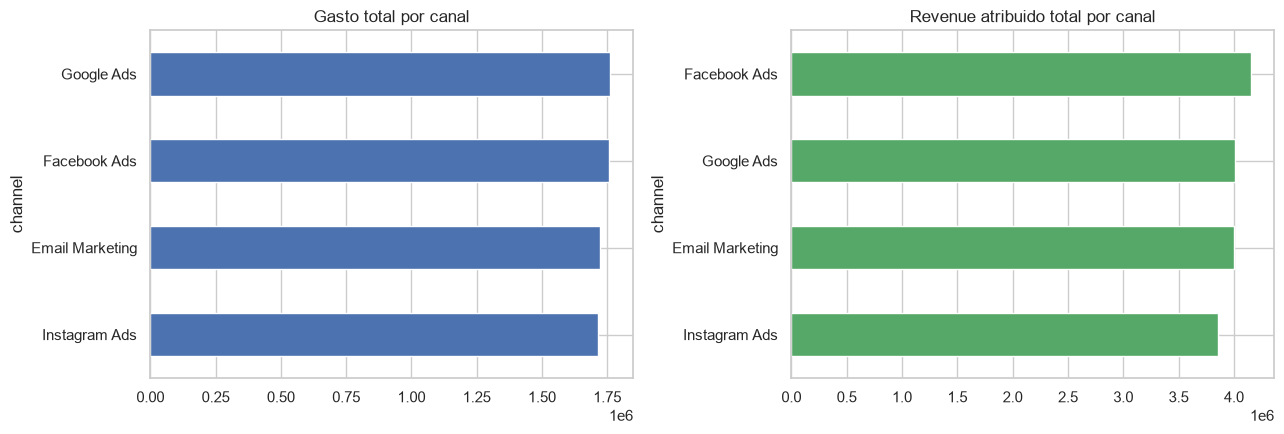

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
by_channel["spend"].sort_values().plot(kind="barh", ax=axes[0], color="#4C72B0")
axes[0].set_title("Gasto total por canal")
by_channel["attributed_revenue"].sort_values().plot(kind="barh", ax=axes[1], color="#55A868")
axes[1].set_title("Revenue atribuido total por canal")
fig.tight_layout()

## ROAS y CAC mensual por canal

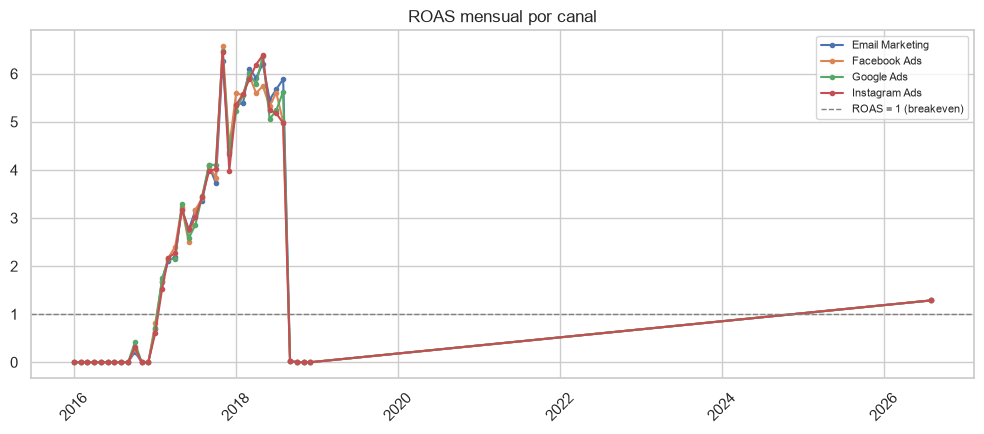

In [5]:
monthly = perf.groupby(["channel", "month"]).agg(
    spend=("spend", "sum"),
    attributed_revenue=("attributed_revenue", "sum"),
    attributed_new_customers=("attributed_new_customers", "sum"),
).reset_index()
monthly["roas"] = monthly["attributed_revenue"] / monthly["spend"]
monthly["cac"] = monthly["spend"] / monthly["attributed_new_customers"].replace(0, float("nan"))

fig, ax = plt.subplots(figsize=(10, 4.5))
for channel, sub in monthly.groupby("channel"):
    ax.plot(sub["month"], sub["roas"], marker="o", markersize=3, label=channel)
ax.axhline(1.0, color="grey", linestyle="--", linewidth=1, label="ROAS = 1 (breakeven)")
ax.set_title("ROAS mensual por canal")
ax.legend(fontsize=8)
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()

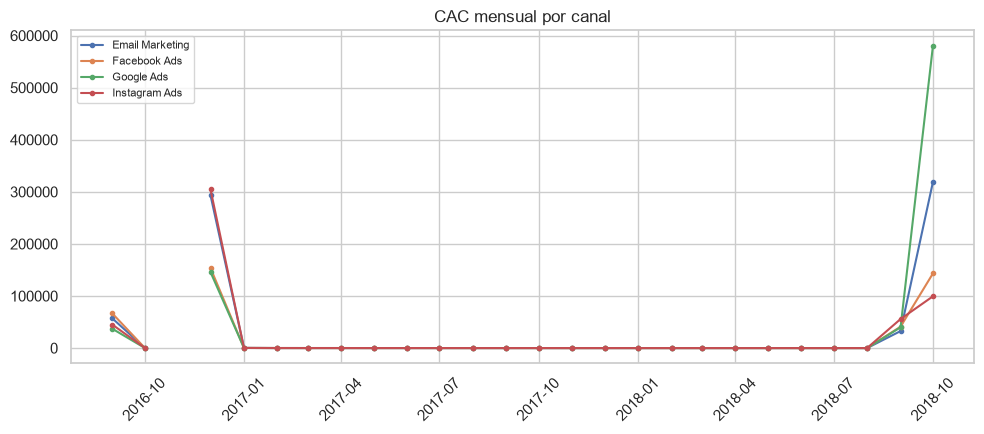

In [6]:
fig, ax = plt.subplots(figsize=(10, 4.5))
for channel, sub in monthly.groupby("channel"):
    ax.plot(sub["month"], sub["cac"], marker="o", markersize=3, label=channel)
ax.set_title("CAC mensual por canal")
ax.legend(fontsize=8)
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()

## Gasto real vs. meta de presupuesto

Solo para los meses con `budget_target` no nulo (operación actual).

In [7]:
budget_months = perf[perf["budget_target"].notna()]
print(f"Meses con budget_target: {budget_months['month'].nunique()} "
      f"({budget_months['month'].min()} a {budget_months['month'].max()})")

vs_budget = budget_months.groupby(["channel", "month"]).agg(
    spend=("spend", "sum"),
    budget_target=("budget_target", "first"),
).reset_index()
vs_budget["pct_of_budget"] = (vs_budget["spend"] / vs_budget["budget_target"] * 100).round(1)
vs_budget.sort_values(["channel", "month"])

Meses con budget_target: 1 (2026-08-01 00:00:00 a 2026-08-01 00:00:00)


,channel,month,spend,budget_target,pct_of_budget
0,Email Marketing,2026-08-01,1256.50,47700.96,2.6
1,Facebook Ads,2026-08-01,1879.54,17131.71,11.0
2,Google Ads,2026-08-01,2006.77,32940.70,6.1
3,Instagram Ads,2026-08-01,2692.03,13029.95,20.7


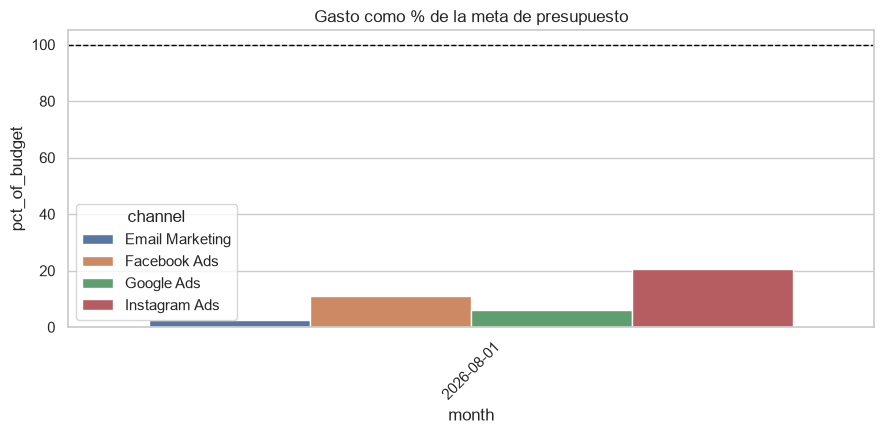

In [8]:
if not vs_budget.empty:
    fig, ax = plt.subplots(figsize=(9, 4.5))
    width = 6
    channels = vs_budget["channel"].unique()
    x = range(len(vs_budget["month"].unique()))
    sns.barplot(data=vs_budget, x="month", y="pct_of_budget", hue="channel", ax=ax)
    ax.axhline(100, color="black", linestyle="--", linewidth=1)
    ax.set_title("Gasto como % de la meta de presupuesto")
    ax.tick_params(axis="x", rotation=45)
    fig.tight_layout()
else:
    print("Sin meses con budget_target -- nada que graficar todavía.")

## Conclusiones

- El ranking de canales por ROAS y por gasto total no necesariamente coincide -- vale la pena revisar si el canal con más presupuesto es también el más eficiente.
- `roas`/`cac` son estimaciones derivadas de `spend_share`, no atribución medida a nivel de orden -- cualquier recomendación de reasignar presupuesto debería señalar esta limitación.
- La comparación contra `budget_target` solo cubre el período de operación actual; el histórico Olist no tiene meta de referencia.